## 1. Cài thư viện

In [1]:
!pip install underthesea datasets huggingface_hub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 53.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.4 MB/s eta 0:00:00


## 2. Import & GPU

In [2]:
import os, re, time, random, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

from sklearn.metrics import classification_report, f1_score


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


## 3. Hyperparameters

In [3]:
MAX_VOCAB   = 15_000
MAX_LEN     = 128
EMBED_DIM   = 300
HIDDEN_DIM  = 128
NUM_LAYERS  = 2
DROPOUT     = 0.8
BATCH_SIZE  = 128
NUM_EPOCHS  = 20
LR          = 2e-4
PATIENCE    = 4
NUM_CLASSES = 2
PAD_TOKEN   = '<PAD>'
UNK_TOKEN   = '<UNK>'
LABEL_NAMES = ['NON-HATE', 'HATE']
CKPT_NAME   = 'best_bilstm_vozhsd.pt'
PLOT_TITLE  = 'BiLSTM — VOZ-HSD'

SAMPLE_SIZE  = 200_000
RANDOM_STATE = 42


## 4. Load Dataset

In [4]:
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset
import huggingface_hub

secret_label = "HF_TOKEN"
secret_value = UserSecretsClient().get_secret(secret_label)
huggingface_hub.login(token=secret_value, add_to_git_credential=False)

# VOZ-HSD chỉ có split "train" — stratified sample 100k, giữ tỉ lệ class tự nhiên
ds = load_dataset("tarudesu/VOZ-HSD", split="train")
full_df = ds.to_pandas()[["texts", "labels"]]
full_df = full_df.rename(columns={"texts": "free_text", "labels": "label_id"})

sampled_df = (
    full_df
    .groupby("label_id", group_keys=False)
    .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(full_df), random_state=RANDOM_STATE))
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Full dataset : {len(full_df):,} rows")
print(f"Sampled      : {len(sampled_df):,} rows")
print()
print("Tỉ lệ class trong full dataset:")
print(full_df["label_id"].value_counts(normalize=True).sort_index().rename({0: "NON-HATE", 1: "HATE"}).round(4))
print()
print("Tỉ lệ class sau sampling:")
print(sampled_df["label_id"].value_counts(normalize=True).sort_index().rename({0: "NON-HATE", 1: "HATE"}).round(4))


README.md: 0.00B [00:00, ?B/s]

data.csv:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10747733 [00:00<?, ? examples/s]

Full dataset : 10,747,733 rows
Sampled      : 200,000 rows

Tỉ lệ class trong full dataset:
label_id
NON-HATE    0.9456
HATE        0.0544
Name: proportion, dtype: float64

Tỉ lệ class sau sampling:
label_id
NON-HATE    0.9456
HATE        0.0544
Name: proportion, dtype: float64


/tmp/ipykernel_57/661921513.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(full_df), random_state=RANDOM_STATE))


## 5. Label Mapping

In [5]:
label_map = {0: 'NON-HATE', 1: 'HATE'}

# Chia train/dev/test (80/10/10)
n       = len(sampled_df)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train_df = sampled_df.iloc[:n_train].reset_index(drop=True)
val_df   = sampled_df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = sampled_df.iloc[n_train+n_val:].reset_index(drop=True)

print(f"Train: {len(train_df):,} | Dev: {len(val_df):,} | Test: {len(test_df):,}")
print()
for split_name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = df["label_id"].value_counts().sort_index().rename(label_map)
    print(f"  {split_name}: {dist.to_dict()}")
train_df.head(3)


Train: 160,000 | Dev: 20,000 | Test: 20,000

  Train: {'NON-HATE': 151274, 'HATE': 8726}
  Val: {'NON-HATE': 18920, 'HATE': 1080}
  Test: {'NON-HATE': 18929, 'HATE': 1071}


,free_text,label_id
0,"cái gì ra cái đó, đoạn clip quay từ sau thấy r...",0
1,Chuyên gia phán cũng ncl thì để mấy em nói đã ...,0
2,football without origi is nothing,0


## 6. Tiền xử lý văn bản

In [6]:
from underthesea import word_tokenize

TEENCODE_MAP = {
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao',
    'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được',
    'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ',
    'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',
    'iu': 'yêu', 'ieu': 'yêu',
    'h': 'bây giờ'
}


def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [TEENCODE_MAP.get(w, w) for w in words]
    return ' '.join(words)


def preprocess(text: str) -> str:
    text = normalize_text(text)
    if text:
        try:
            text = word_tokenize(text, format='text')
        except Exception:
            pass
    return text


def tokenize(text: str) -> list:
    processed = preprocess(text)
    tokens = processed.split()
    return tokens if tokens else [UNK_TOKEN]


sample = 'mày ko hiểu gì hết, ngu vcl!!'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')
print(f'Tokens   : {tokenize(sample)}')


Original : mày ko hiểu gì hết, ngu vcl!!
Processed: mày không hiểu gì hết ngu_vãi cái lồn
Tokens   : ['mày', 'không', 'hiểu', 'gì', 'hết', 'ngu_vãi', 'cái', 'lồn']


## 7. Áp dụng tiền xử lý

In [7]:
%%time
print("Preprocessing texts...")
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    df['tokens'] = df['free_text'].apply(tokenize)
    print(f'  {name}: done')

lens = train_df['tokens'].apply(len)
print(f'\nĐộ dài câu — mean: {lens.mean():.1f} | max: {lens.max()} | 95th: {np.percentile(lens, 95):.0f}')
print()
print("Sample:")
for _, row in train_df.sample(3, random_state=42).iterrows():
    lbl = label_map[row['label_id']]
    print(f'  [{lbl:>8}] {row["free_text"][:50]} -> {str(row["tokens"][:6])}')


Preprocessing texts...
  Train: done
  Val: done
  Test: done

Độ dài câu — mean: 24.4 | max: 2962 | 95th: 69

Sample:
  [NON-HATE] có bạn ạ đủ tiền mua đ.c cái pedal điện -> ['có', 'bạn', 'ạ', 'đủ', 'tiền', 'mua']
  [NON-HATE] Vì nó là 1 “pure talent”, trừ sức mạnh ra, mọi chỉ -> ['vì', 'nó', 'là', '1', 'pure', 'talent_trừ']
  [NON-HATE] nãy bên khách cho cái stk mà lại cái là tự nhiên c -> ['nãy', 'bên', 'khách', 'cho', 'cái', 'stk']
CPU times: user 4min, sys: 227 ms, total: 4min
Wall time: 4min


## 8. Vocabulary & Embedding

In [8]:
class Vocabulary:
    def __init__(self, max_size=MAX_VOCAB):
        self.max_size = max_size
        self.word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
        self.idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}

    def build(self, token_lists):
        counter = Counter(tok for tokens in token_lists for tok in tokens)
        for word, _ in counter.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f'Vocabulary size: {len(self.word2idx):,}')

    def encode(self, tokens, max_len=None):
        ml  = max_len or MAX_LEN
        ids = [self.word2idx.get(t, 1) for t in tokens[:ml]]
        ids += [0] * (ml - len(ids))
        return ids

vocab = Vocabulary()
vocab.build(train_df['tokens'])


Vocabulary size: 14,999


In [9]:
import gzip, shutil

def load_pretrained_embeddings(vocab, embed_dim,
                               vec_path='/kaggle/input/datasets/mnhtndev/fasttext-vi/cc.vi.300.vec'):
    gz_path = vec_path + '.gz'
    if not os.path.exists(vec_path) and os.path.exists(gz_path):
        print('Giải nén...')
        with gzip.open(gz_path, 'rb') as fi, open(vec_path, 'wb') as fo:
            shutil.copyfileobj(fi, fo)

    print('Loading fastText vectors...')
    ft = {}
    with open(vec_path, 'r', encoding='utf-8') as f:
        total, dim = map(int, f.readline().strip().split())
        print(f'  {total:,} từ, {dim} chiều')
        for i, line in enumerate(f):
            parts = line.rstrip().split(' ')
            if parts[0] in vocab.word2idx:
                ft[parts[0]] = np.array(parts[1:], dtype=np.float32)
            if (i + 1) % 500_000 == 0:
                print(f'  {i+1:,} / {total:,}')

    V      = len(vocab.word2idx)
    matrix = np.zeros((V, embed_dim), dtype=np.float32)
    found  = 0
    for word, idx in vocab.word2idx.items():
        if word in ft:
            matrix[idx] = ft[word]; found += 1
        else:
            matrix[idx] = np.random.uniform(-0.1, 0.1, embed_dim)
    matrix[0] = 0  # <PAD> = zero vector
    print(f'Embedding matrix: {matrix.shape} | coverage: {found/V*100:.1f}%')
    return matrix

embedding_matrix = load_pretrained_embeddings(vocab, EMBED_DIM)


Loading fastText vectors...
  2,000,000 từ, 300 chiều
  500,000 / 2,000,000
  1,000,000 / 2,000,000
  1,500,000 / 2,000,000
  2,000,000 / 2,000,000
Embedding matrix: (14999, 300) | coverage: 49.2%


## 9. Dataset & DataLoader

In [10]:
class HSDDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.inputs  = [vocab.encode(toks, max_len) for toks in df['tokens']]
        self.lengths = [max(1, min(len(toks), max_len)) for toks in df['tokens']]
        self.labels  = df['label_id'].tolist()

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx],  dtype=torch.long),
            torch.tensor(self.lengths[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],  dtype=torch.long),
        )

train_ds = HSDDataset(train_df, vocab)
val_ds   = HSDDataset(val_df,   vocab)
test_ds  = HSDDataset(test_df,  vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


Batches — Train: 1250 | Val: 157 | Test: 157


## 10. Model BiLSTM

In [11]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes, dropout, embedding_matrix=None, freeze_embed=False):
        super().__init__()

        # ── Embedding ────────────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(embedding_matrix, dtype=torch.float32)
            )
            if freeze_embed:
                self.embedding.weight.requires_grad = False
        self.embed_dropout = nn.Dropout(dropout)

        # ── BiLSTM ───────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        # ── Attention — 2-layer để học context tốt hơn ──────────
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False),
        )

        # ── Classifier head ──────────────────────────────────────
        # Input: attention context (2H) + last hidden state (2H) = 4H
        self.layer_norm = nn.LayerNorm(hidden_dim * 4)
        self.dropout    = nn.Dropout(dropout)
        self.dropout2   = nn.Dropout(dropout * 0.5)   # nhẹ hơn sau fc1
        self.fc1        = nn.Linear(hidden_dim * 4, hidden_dim)
        self.bn1        = nn.BatchNorm1d(hidden_dim)
        self.fc2        = nn.Linear(hidden_dim, num_classes)
        self.relu       = nn.ReLU()

    def attention_pooling(self, lstm_out, lengths):
        scores  = self.attention(lstm_out).squeeze(-1)        # (B, T)
        mask    = torch.arange(lstm_out.size(1), device=lstm_out.device)
        mask    = mask.unsqueeze(0) >= lengths.unsqueeze(1)   # True = pad
        scores  = scores.masked_fill(mask, float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        return (lstm_out * weights).sum(dim=1)                # (B, 2H)

    def forward(self, x, lengths):
        # Embedding
        emb = self.embed_dropout(self.embedding(x))           # (B, T, E)

        # BiLSTM
        packed       = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        lstm_out, (h, _) = self.bilstm(packed)
        lstm_out, _  = pad_packed_sequence(lstm_out, batch_first=True, total_length=x.size(1))

        # Attention context
        attn_out = self.attention_pooling(lstm_out, lengths)   # (B, 2H)

        # Last hidden state của cả 2 chiều từ layer cuối
        # h: (num_layers*2, B, H) → lấy 2 chiều của layer cuối
        last_h = torch.cat([h[-2], h[-1]], dim=-1)             # (B, 2H)

        # Concat attention + last hidden → richer representation
        combined = torch.cat([attn_out, last_h], dim=-1)       # (B, 4H)
        combined = self.layer_norm(combined)

        # Classifier
        out = self.dropout(combined)
        out = self.relu(self.bn1(self.fc1(out)))               # (B, H)
        out = self.dropout2(out)
        return self.fc2(out)                                   # (B, C)


model = BiLSTMClassifier(
    vocab_size       = len(vocab.word2idx),
    embed_dim        = EMBED_DIM,
    hidden_dim       = HIDDEN_DIM,
    num_layers       = NUM_LAYERS,
    num_classes      = NUM_CLASSES,
    dropout          = DROPOUT,
    embedding_matrix = embedding_matrix,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {total_params:,}')
print(model)

Trainable params: 5,435,510
BiLSTMClassifier(
  (embedding): Embedding(14999, 300, padding_idx=0)
  (embed_dropout): Dropout(p=0.8, inplace=False)
  (bilstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.8, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=False)
  )
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.8, inplace=False)
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)


## 11. Loss, Optimizer & Scheduler

In [12]:
# Class weights
y_train_tensor = torch.tensor(train_df['label_id'].values, dtype=torch.long)
counts         = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
class_weights  = (len(train_df) / (NUM_CLASSES * counts)).to(DEVICE)
print('Class weights:', class_weights.cpu().numpy().round(3))

# Loss
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-3,   
    eps          = 1e-6,
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'max',
    factor   = 0.5,
    patience = 3,          
    min_lr   = 1e-6,
)

Class weights: [0.529 9.168]


## 12. Training

In [13]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = total_correct = total_n = 0
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss    += loss.item() * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_n       += y.size(0)
    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_correct = total_n = 0
    all_preds, all_labels = [], []
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        logits = model(x, lengths)
        loss   = criterion(logits, y)
        preds  = logits.argmax(1)
        total_loss    += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total_n       += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total_n, total_correct / total_n, macro_f1


In [14]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1, best_epoch, patience_counter = 0, 0, 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6} | {'Time':>6}")
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc         = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_f1 = evaluate(model, val_loader, criterion)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    scheduler.step(vl_f1)

    flag = ''
    if vl_f1 > best_f1:
        best_f1, best_epoch = vl_f1, epoch
        torch.save(model.state_dict(), CKPT_NAME)
        patience_counter = 0
        flag = ' saved'
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} | {elapsed:>5.1f}s{flag}')

print(f'\nBest Val F1 = {best_f1:.4f} at epoch {best_epoch}')


 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1 |   Time
------------------------------------------------------------------------
     1 |     0.8639 |    0.2698 |   0.7912 |  0.4252 | 0.3607 |  49.8s saved
     2 |     0.7951 |    0.3810 |   0.7789 |  0.4293 | 0.3635 |  49.2s saved
     3 |     0.7818 |    0.4400 |   0.7792 |  0.5469 | 0.4382 |  49.6s saved
     4 |     0.7733 |    0.4909 |   0.7711 |  0.5256 | 0.4249 |  49.6s
     5 |     0.7680 |    0.5337 |   0.7717 |  0.6538 | 0.5055 |  49.5s saved
     6 |     0.7623 |    0.5622 |   0.7675 |  0.6631 | 0.5117 |  49.4s saved
     7 |     0.7585 |    0.5868 |   0.7694 |  0.7689 | 0.5864 |  49.3s saved
     8 |     0.7532 |    0.6088 |   0.7683 |  0.8075 | 0.6184 |  49.7s saved
     9 |     0.7528 |    0.6275 |   0.7691 |  0.8343 | 0.6432 |  49.6s saved
    10 |     0.7487 |    0.6401 |   0.7694 |  0.8289 | 0.6380 |  49.8s
    11 |     0.7458 |    0.6583 |   0.7750 |  0.8655 | 0.6743 |  49.9s saved
    12 |     0.7475 |

## 13. Training Curves

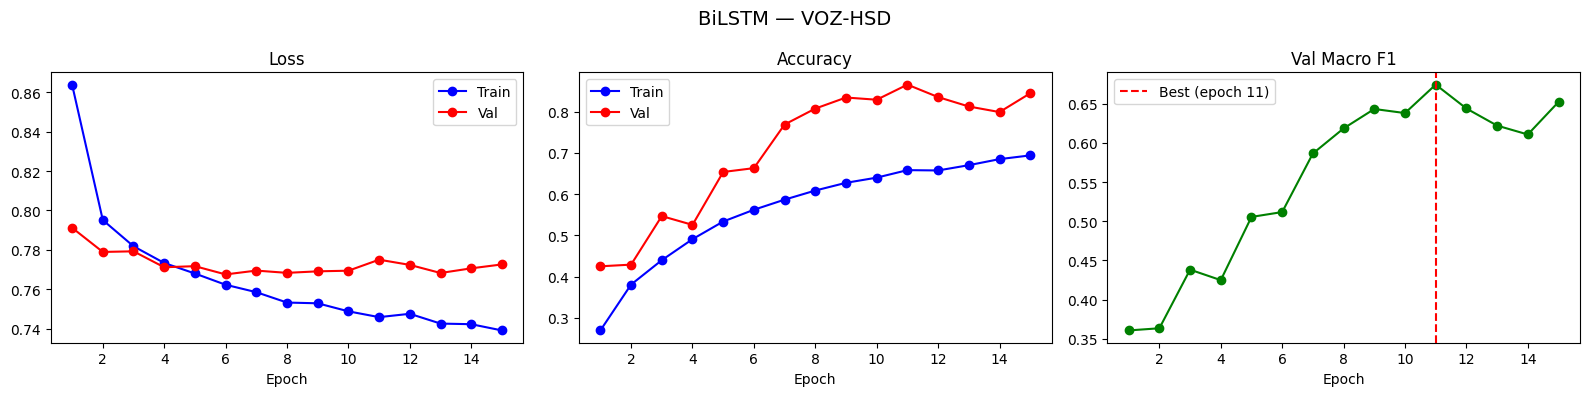

In [15]:
n            = len(history['train_loss'])
epochs_range = range(1, n + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], 'g-o')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].set_title('Val Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle(PLOT_TITLE, fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


## 14. Đánh giá Test Set

In [16]:
model.load_state_dict(torch.load(CKPT_NAME, map_location=DEVICE))

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for x, lengths, y in loader:
        x, lengths = x.to(DEVICE), lengths.to(DEVICE)
        logits = model(x, lengths)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)

print('Classification Report — Test Set')
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))


Classification Report — Test Set
              precision    recall  f1-score   support

    NON-HATE     0.9940    0.8626    0.9237     18929
        HATE     0.2721    0.9076    0.4187      1071

    accuracy                         0.8650     20000
   macro avg     0.6330    0.8851    0.6712     20000
weighted avg     0.9553    0.8650    0.8966     20000



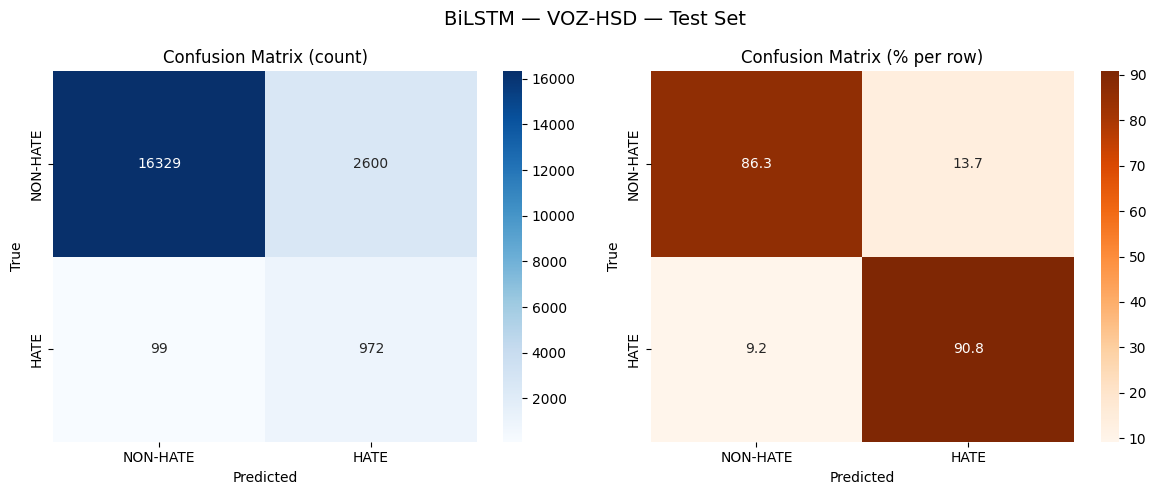

In [17]:
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm,     annot=True, fmt='d',   cmap='Blues',   ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[0].set_title('Confusion Matrix (count)')
axes[1].set_title('Confusion Matrix (% per row)')
for ax in axes:
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle(PLOT_TITLE + ' — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 15. Kiểm chứng nhanh

In [18]:
@torch.no_grad()
def predict(texts):
    model.eval()
    results = []
    for text in texts:
        tokens  = tokenize(text)
        ids     = vocab.encode(tokens, MAX_LEN)
        length  = max(1, min(len(tokens), MAX_LEN))
        x       = torch.tensor([ids],    dtype=torch.long).to(DEVICE)
        l_t     = torch.tensor([length], dtype=torch.long).to(DEVICE)
        logits  = model(x, l_t)
        probs   = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
        pred_id = int(probs.argmax())
        results.append({
            'text'  : text,
            'label' : LABEL_NAMES[pred_id],
            'scores': {LABEL_NAMES[i]: round(float(p), 4) for i, p in enumerate(probs)},
        })
    return results


TEST_CASES = [
    ("Hôm nay trời đẹp quá, đi chơi thôi!",                  "NON-HATE"),
    ("Tụi nó toàn nói nhảm, đúng là quá toxic",               "NON-HATE"),
    ("Đồ ngu, câm miệng lại đi mày",                          "NON-HATE"),
    ("Tao ghét cái loại người như mày, xéo đi cho khuất mắt", "HATE"),
    ("Cảm ơn bạn đã giúp đỡ mình nhé!",                       "NON-HATE"),
    ("Tao cảm ơn mày nhiều lắm",                              "NON-HATE"),
    ("nguyên cả cái tỉnh này không được khôn lắm",                              "HATE"),
]

correct = 0
for text, expected in TEST_CASES:
    r     = predict([text])[0]
    match = 'OK' if r['label'] == expected else 'WRONG'
    if r['label'] == expected:
        correct += 1
    prob_str = ' | '.join([f'{k}: {v:.2f}' for k, v in r['scores'].items()])
    print(f'Input   : {text}')
    print(f'Expected: {expected}')
    print(f'  Pred  : {r["label"]:<10} {match:<6} {prob_str}')
    print()

print(f'Summary: {correct}/{len(TEST_CASES)}  ({correct/len(TEST_CASES)*100:.0f}%)')


Input   : Hôm nay trời đẹp quá, đi chơi thôi!
Expected: NON-HATE
  Pred  : NON-HATE   OK     NON-HATE: 0.52 | HATE: 0.48

Input   : Tụi nó toàn nói nhảm, đúng là quá toxic
Expected: NON-HATE
  Pred  : HATE       WRONG  NON-HATE: 0.17 | HATE: 0.83

Input   : Đồ ngu, câm miệng lại đi mày
Expected: NON-HATE
  Pred  : HATE       WRONG  NON-HATE: 0.01 | HATE: 0.99

Input   : Tao ghét cái loại người như mày, xéo đi cho khuất mắt
Expected: HATE
  Pred  : HATE       OK     NON-HATE: 0.01 | HATE: 0.99

Input   : Cảm ơn bạn đã giúp đỡ mình nhé!
Expected: NON-HATE
  Pred  : NON-HATE   OK     NON-HATE: 0.52 | HATE: 0.48

Input   : Tao cảm ơn mày nhiều lắm
Expected: NON-HATE
  Pred  : HATE       WRONG  NON-HATE: 0.32 | HATE: 0.68

Input   : nguyên cả cái tỉnh này không được khôn lắm
Expected: HATE
  Pred  : HATE       OK     NON-HATE: 0.12 | HATE: 0.88

Summary: 4/7  (57%)


## 16. Lưu model

In [19]:
os.makedirs('outputs', exist_ok=True)

with open('outputs/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

config = {
    'MAX_VOCAB': MAX_VOCAB, 'MAX_LEN': MAX_LEN, 'EMBED_DIM': EMBED_DIM,
    'HIDDEN_DIM': HIDDEN_DIM, 'NUM_LAYERS': NUM_LAYERS, 'DROPOUT': DROPOUT,
    'NUM_CLASSES': NUM_CLASSES, 'LABEL_NAMES': LABEL_NAMES,
    'best_epoch': best_epoch, 'best_val_f1': round(best_f1, 4),
    'test_macro_f1': round(float(f1_score(y_true, y_pred, average='macro')), 4),
    'test_f1_hate':  round(float(f1_score(y_true, y_pred, labels=[LABEL_NAMES.index('HATE')], average='macro')), 4),
}
with open('outputs/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"Test Macro F1 : {config['test_macro_f1']:.4f}")
print(f"Test F1 HATE  : {config['test_f1_hate']:.4f}")
print(f"Checkpoint    : {CKPT_NAME}")
print(f"Saved to      : outputs/")


Test Macro F1 : 0.6712
Test F1 HATE  : 0.4187
Checkpoint    : best_bilstm_vozhsd.pt
Saved to      : outputs/
